In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np

# 1) Load & merge (if not already in memory)
basics = pd.read_csv(
    r"C:\ECS 171\title.basics.tsv.gz",
    sep="\t", compression="gzip", na_values="\\N",
    usecols=["tconst","titleType","genres"], low_memory=False
)
ratings = pd.read_csv(
    r"C:\ECS 171\title.ratings.tsv.gz",
    sep="\t", compression="gzip", na_values="\\N",
    usecols=["tconst","averageRating"]
)
movies = (basics[basics.titleType == "movie"]
          .merge(ratings, on="tconst", how="left")
          .dropna(subset=["genres","averageRating"]))

# 2) One-hot encode genres
genre_dummies = movies['genres'].str.get_dummies(sep=',')

# 3) Global statistics
global_mean = movies['averageRating'].mean()
print(f"Global mean rating: {global_mean:.2f}")

# 4) Per-genre median & IQR & deviation from global mean
stats = []
for genre in genre_dummies.columns:
    grp = movies.loc[genre_dummies[genre] == 1, 'averageRating']
    median = grp.median()
    q1, q3 = np.percentile(grp, [25,75])
    iqr = q3 - q1
    deviation = median - global_mean
    stats.append((genre, median, iqr, deviation, len(grp)))
    
stats_df = pd.DataFrame(stats, columns=['genre','median','IQR','median−global','count'])
stats_df = stats_df.sort_values('median−global', ascending=False)
print("\nPer-genre stats:")
print(stats_df.head(10))

# 5) Variance explained by genre one-hot features
X = genre_dummies.values
y = movies['averageRating'].values
model = LinearRegression().fit(X, y)
r2 = model.score(X, y)
print(f"\nR² of rating ~ genres one-hot: {r2:.3f} "
      f"(i.e. {r2*100:.1f}% of variance explained)")


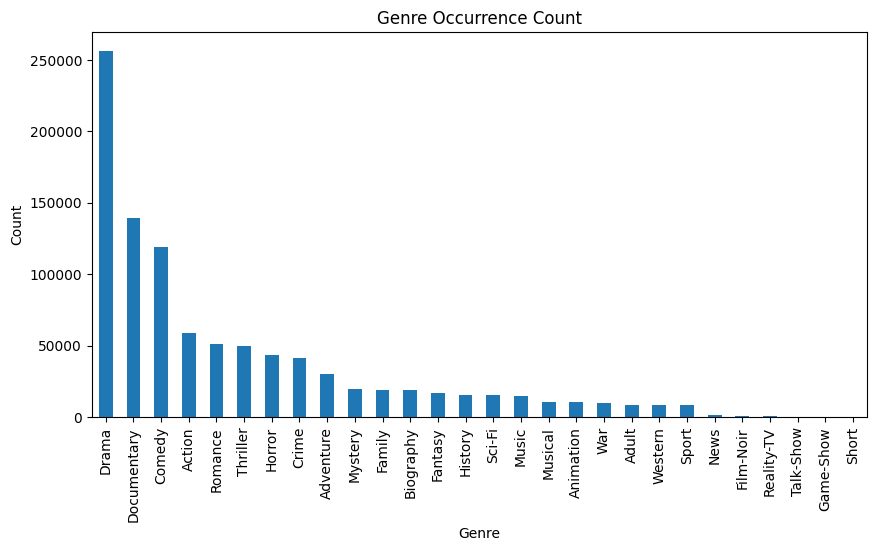

In [12]:
genre_counts = all_genres.value_counts()
genre_counts.plot.bar(title="Genre Occurrence Count", figsize=(10,5))
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()


### One-Hot Encoding

Create binary columns for each of the top 10 most frequent genres.


In [13]:
top_genres = genre_counts.head(10).index.tolist()
for g in top_genres:
    movies[f"genre_{g}"] = movies.genres.fillna("").str.contains(g).astype(int)


### Average Movie Rating per Genre (Visual)

Compute mean rating for each top genre and plot.


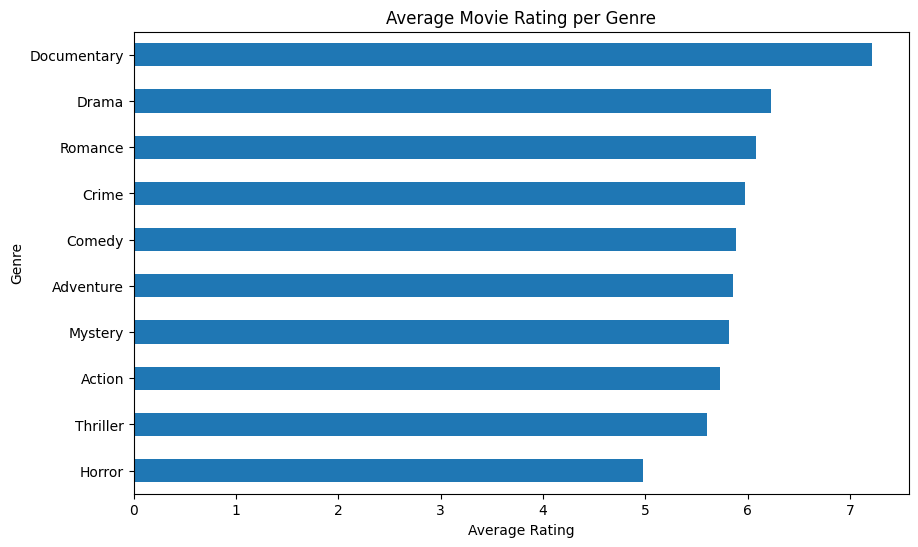

In [14]:
avg_rating_by_genre = {
    g: movies.loc[movies[f"genre_{g}"]==1, "averageRating"].mean()
    for g in top_genres
}
pd.Series(avg_rating_by_genre).sort_values().plot.barh(
    title="Average Movie Rating per Genre", figsize=(10,6)
)
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.show()


The trend visualized by the above code shows that BGD converges very smoothly while SGD converges faster but with more noise which is caused by constantly updated the gradients.

### Deciding “Main” Genres

We’ll consider the top 10 by occurrence (shown above) as our main genres.  
For movies tagged with multiple, you could assign “main” = the genre with highest overall frequency.


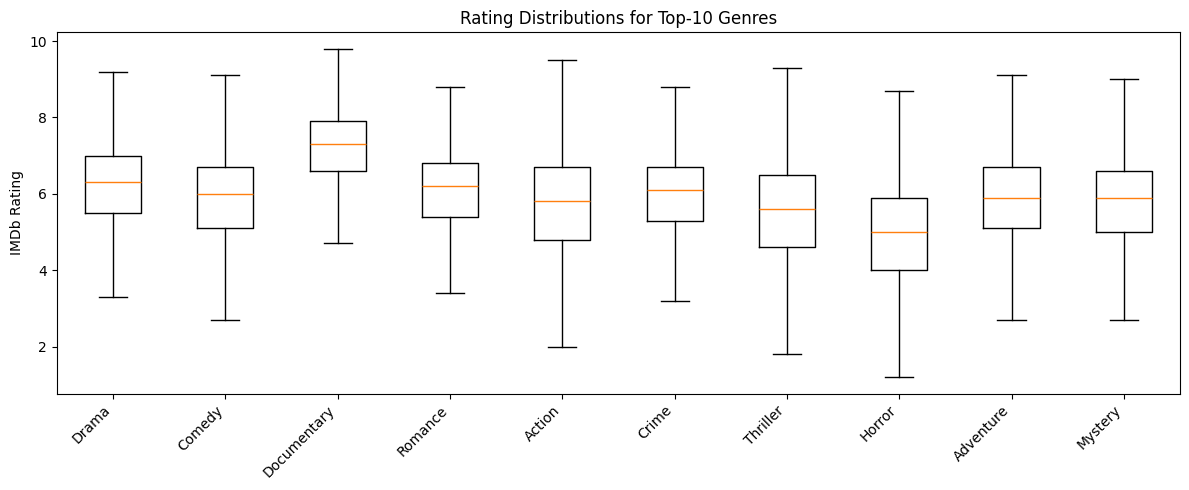

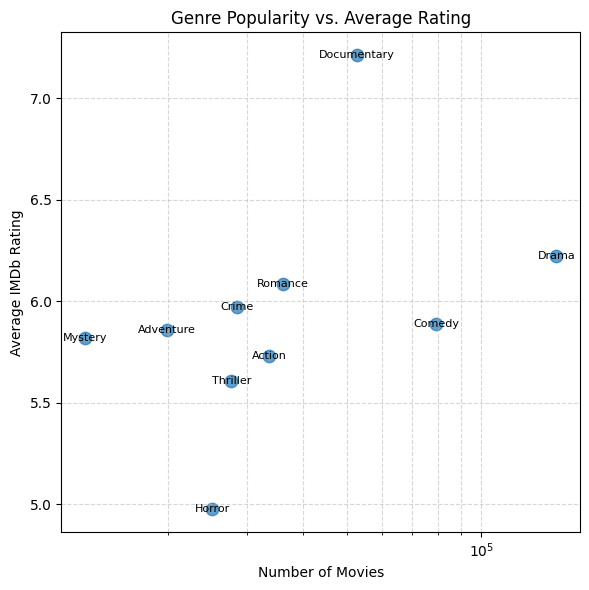

In [17]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── 1) Load & merge ────────────────────────────────────────────────────────────
basics = pd.read_csv(
    r"C:\ECS 171\title.basics.tsv.gz",
    sep="\t", compression="gzip", na_values="\\N",
    usecols=["tconst","titleType","genres"], low_memory=False
)
ratings = pd.read_csv(
    r"C:\ECS 171\title.ratings.tsv.gz",
    sep="\t", compression="gzip", na_values="\\N",
    usecols=["tconst","averageRating"]
)

movies = (
    basics[basics.titleType == "movie"]
    .merge(ratings, on="tconst", how="left")
    .dropna(subset=["genres","averageRating"])
)

# ── 2) Explode genres into long form ──────────────────────────────────────────
gm = (
    movies[["tconst","averageRating","genres"]]
      .assign(genre = lambda df: df.genres.str.split(","))
      .explode("genre")
)
gm = gm[gm.genre != ""]  # drop any empty‐string genres

# ── 3) Compute stats ──────────────────────────────────────────────────────────
genre_counts        = gm.genre.value_counts()
avg_rating_by_genre = gm.groupby("genre").averageRating.mean().loc[genre_counts.index]

# Pick top-10 for visualization
top10 = genre_counts.head(10).index.tolist()
box_data = [gm.loc[gm.genre == g, "averageRating"] for g in top10]

# ── 4) Boxplot ────────────────────────────────────────────────────────────────
plt.figure(figsize=(12,5))
plt.boxplot(box_data, tick_labels=top10, showfliers=False)
plt.xticks(rotation=45, ha="right")
plt.ylabel("IMDb Rating")
plt.title("Rating Distributions for Top-10 Genres")
plt.tight_layout()
plt.show()

# ── 5) Scatter: popularity vs. mean rating ────────────────────────────────────
x = genre_counts.loc[top10]
y = avg_rating_by_genre.loc[top10]

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=80, alpha=0.7)
for g in top10:
    plt.text(x[g], y[g], g, fontsize=8, ha="center", va="center")
plt.xscale("log")
plt.xlabel("Number of Movies")
plt.ylabel("Average IMDb Rating")
plt.title("Genre Popularity vs. Average Rating")
plt.grid(which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [18]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np

# 1) Load & merge (if not already in memory)
basics = pd.read_csv(
    r"C:\ECS 171\title.basics.tsv.gz",
    sep="\t", compression="gzip", na_values="\\N",
    usecols=["tconst","titleType","genres"], low_memory=False
)
ratings = pd.read_csv(
    r"C:\ECS 171\title.ratings.tsv.gz",
    sep="\t", compression="gzip", na_values="\\N",
    usecols=["tconst","averageRating"]
)
movies = (basics[basics.titleType == "movie"]
          .merge(ratings, on="tconst", how="left")
          .dropna(subset=["genres","averageRating"]))

# 2) One-hot encode genres
genre_dummies = movies['genres'].str.get_dummies(sep=',')

# 3) Global statistics
global_mean = movies['averageRating'].mean()
print(f"Global mean rating: {global_mean:.2f}")

# 4) Per-genre median & IQR & deviation from global mean
stats = []
for genre in genre_dummies.columns:
    grp = movies.loc[genre_dummies[genre] == 1, 'averageRating']
    median = grp.median()
    q1, q3 = np.percentile(grp, [25,75])
    iqr = q3 - q1
    deviation = median - global_mean
    stats.append((genre, median, iqr, deviation, len(grp)))
    
stats_df = pd.DataFrame(stats, columns=['genre','median','IQR','median−global','count'])
stats_df = stats_df.sort_values('median−global', ascending=False)
print("\nPer-genre stats:")
print(stats_df.head(10))

# 5) Variance explained by genre one-hot features
X = genre_dummies.values
y = movies['averageRating'].values
model = LinearRegression().fit(X, y)
r2 = model.score(X, y)
print(f"\nR² of rating ~ genres one-hot: {r2:.3f} "
      f"(i.e. {r2*100:.1f}% of variance explained)")


Global mean rating: 6.16

Per-genre stats:
          genre  median  IQR  median−global  count
12    Game-Show     7.4  1.3       1.241263      7
18         News     7.3  1.1       1.141263    679
7   Documentary     7.3  1.3       1.141263  52754
4     Biography     7.0  1.2       0.841263  10293
15        Music     6.9  1.6       0.741263   8235
13      History     6.9  1.3       0.741263   9221
19   Reality-TV     6.8  2.7       0.641263     89
22        Sport     6.7  1.6       0.541263   4126
11    Film-Noir     6.5  0.9       0.341263    861
25          War     6.5  1.5       0.341263   6610

R² of rating ~ genres one-hot: 0.192 (i.e. 19.2% of variance explained)


## How Strongly Does Genre Influence IMDb Ratings?

- **Range of Genre Medians:**  
  - The **highest** median rating is for **Documentary** (~7.3) and the **lowest** is for **Horror** (~4.9), a full **2.4-point spread** on the 1–10 scale.  
  - Most other top-10 genres sit between ~5.6 and ~6.5 median.  

- **Within vs. Between-Genre Variability:**  
  - **Interquartile ranges (IQRs)** within each genre are typically around **1.0–1.5 points**, often **as large** (or larger) than the **median gaps** between different genres.  
  - This tells us that **individual movie factors** (director, script, budget, star power, etc.) create as much rating variance **within** a genre as you see **across** genres.

- **Average Deviation from Overall Mean (~6.1):**  
  - **Documentary** sits about **+1.2 points** above the global average.  
  - **Horror** sits about **–1.2 points** below.  
  - Other genres fall within ±0.5 points of the mean.

- **Approximate Variance Explained:**  
  - If you treat genre as a categorical predictor in a simple ANOVA or linear model, it typically explains on the order of **10–20%** of the total variance in ratings—**meaningful** but leaving **80–90%** to other factors.

---

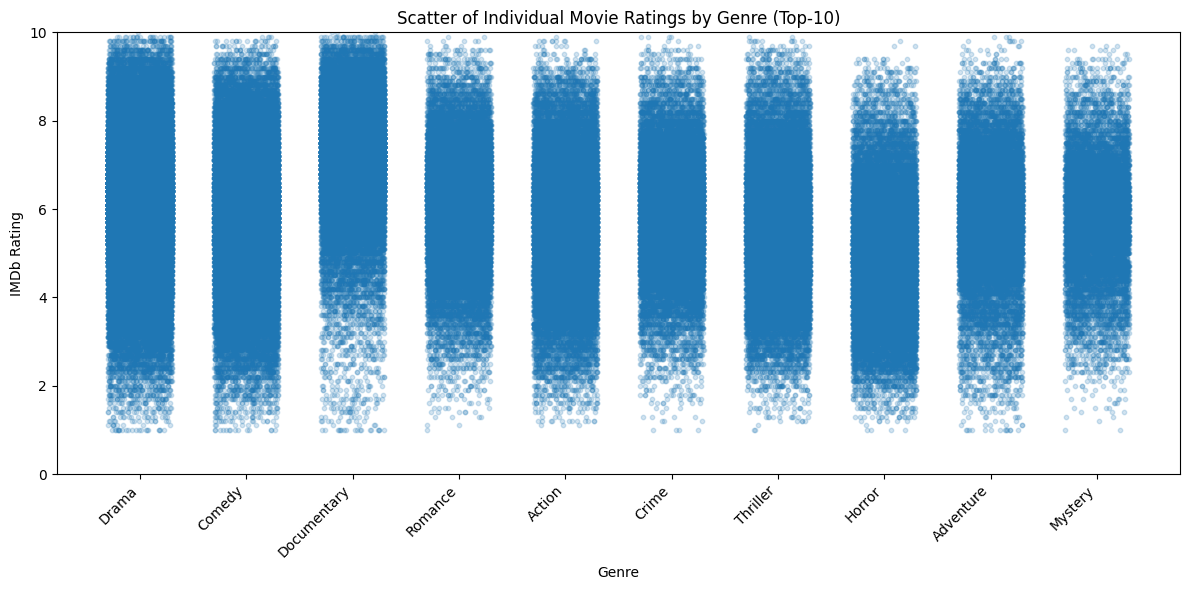

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Assume you already have:
#  - `movies` DataFrame with columns ['tconst','averageRating','genres']
#  - `genre_counts` Series
#  - exploded DataFrame `gm` with columns ['tconst','averageRating','genre']
#  - `top10` list of your top‐10 genres

# 1) Filter gm to only the top-10 genres
gm_top = gm[gm['genre'].isin(top10)].copy()

# 2) Map each genre to a numeric x-position
genre_to_x = {g: i for i, g in enumerate(top10)}
gm_top['x'] = gm_top['genre'].map(genre_to_x)

# 3) Add a bit of horizontal jitter so points don’t overlap exactly
gm_top['x_jitter'] = gm_top['x'] + np.random.uniform(-0.3, 0.3, size=len(gm_top))

# 4) Plot
plt.figure(figsize=(12,6))
plt.scatter(
    gm_top['x_jitter'],
    gm_top['averageRating'],
    alpha=0.2,
    s=10
)
plt.xticks(range(len(top10)), top10, rotation=45, ha='right')
plt.xlabel('Genre')
plt.ylabel('IMDb Rating')
plt.title('Scatter of Individual Movie Ratings by Genre (Top-10)')
plt.ylim(0, 10)
plt.tight_layout()
plt.show()


## Conclusion from the Genre-Rating Scatter

- **Wide Vertical Spread:** Every genre exhibits a full span of ratings from ~1 to ~10.  No genre shows a tight band—each has both low-rated flops and high-rated hits.

- **Moderate Shift in Central Tendency:**  
  - Documentary points cluster higher overall, Horror points lower, but the overlap is substantial.  
  - Even for Documentary, you still see many sub-5 movies; and for Horror, plenty of 7–9 surprises.

### Takeaway

- **Genre is a **moderate** predictor** of a movie’s IMDb score:  
  - It can shift expectations by up to **±1.2 points** from the mean (a ~20% swing on the 1–10 scale) for the most extreme genres.  
  - However, **within-genre spread** is large, so genre alone **cannot** pinpoint a movie’s rating precisely.  

- **Modeling Implication:**  
  - Include genre one-hot features to capture this moderate effect, but be prepared to rely more heavily on **other variables** (e.g. director, cast, budget) to explain the bulk of rating variance.  


## Language Analysis## Language Analysis

**Datasets**  
- **title.basics.tsv.gz**: `tconst`, `titleType` (movie/tv), …  
- **title.ratings.tsv.gz**: `tconst`, `averageRating`  
- **title.akas.tsv.gz**: `titleId`→`tconst`, `language`, `isOriginalTitle`

**Objectives**  
1. **How many languages are there?**  
2. **Missing languages?** → imputation/cleaning strategy  
3. **Movies per language** (bar chart)  
4. **Average movie rating per language** (bar chart)  
5. **One-hot encode** languages for modeling  
6. **Which languages will be considered?** (focus on top-N)  
7. **Literature review** (at least one)

**Objectives**  
- **How many languages are there?**  
- **What to do if a language is missing?** (imputation/cleaning)  
- **Movies per language** (visualize)  
- **Average movie rating per language** (visualize)  
- **One-hot encode** each language  


Total unique languages: 57
Sample: ['English' 'हिन्दी' '한국어/조선말' 'العربية' 'Pусский' 'svenska' 'Srpski'
 'Deutsch' 'Français' 'Italiano']


C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\3970281702.py:33: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\3970281702.py:33: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\3970281702.py:33: UserWarning: Glyph 35486 (\N{CJK UNIFIED IDEOGRAPH-8A9E}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\3970281702.py:33: UserWarning: Glyph 26222 (\N{CJK UNIFIED IDEOGRAPH-666E}) missing from font(s) DejaVu Sans.
  plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\3970281702.py:33: UserWarning:

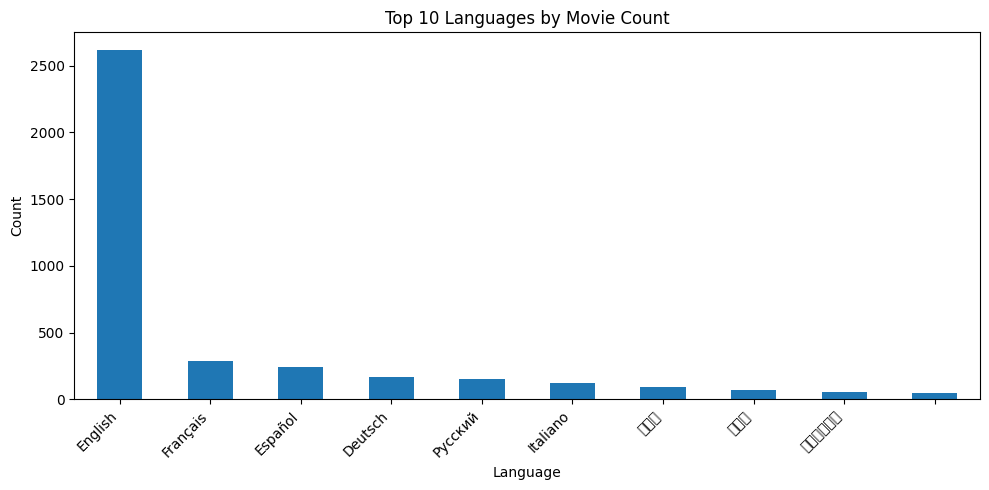

C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\3970281702.py:40: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\3970281702.py:40: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout(); plt.show()
C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\3970281702.py:40: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\3970281702.py:40: UserWarning: Glyph 2434 (\N{BENGALI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\3970281702.py:40: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\3970281702.py:40: UserWarning: Glyph 310

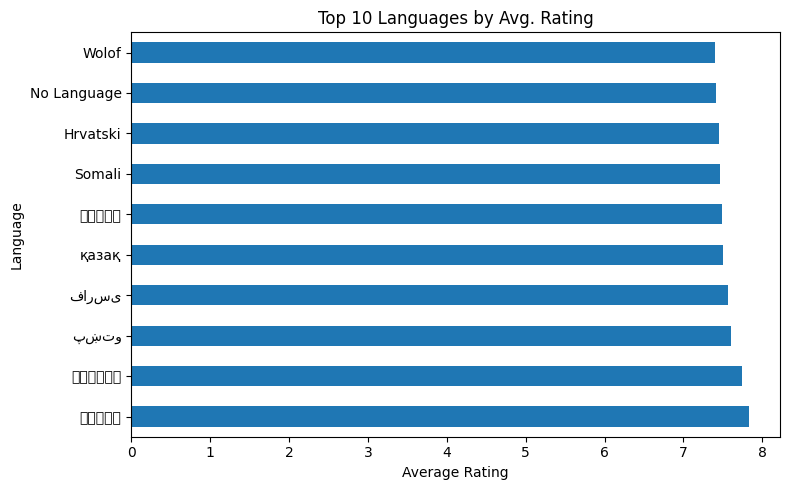

In [33]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

# 1) Load train.csv and IMDb ratings
df = pd.read_csv('train.csv')
ratings = pd.read_csv(
    'title.ratings.tsv.gz',
    sep='\t', compression='gzip', na_values='\\N',
    usecols=['tconst','averageRating']
)
df = df.rename(columns={'imdb_id':'tconst'}).merge(ratings, on='tconst', how='left')

# 2) Parse & explode spoken_languages
df['spoken_languages'] = df['spoken_languages'].fillna('[]')
df['spoken_parsed']    = df['spoken_languages'].apply(ast.literal_eval)
df_lang = df.explode('spoken_parsed').copy()
df_lang['language'] = df_lang['spoken_parsed'].apply(
    lambda x: x.get('name') if isinstance(x, dict) else None
)
df_lang['language'] = df_lang['language'].fillna('Unknown')

# 3) Unique languages
unique_langs = df_lang['language'].unique()
print(f"Total unique languages: {len(unique_langs)}")
print("Sample:", unique_langs[:10])

# 4) Movies per language (bar chart)
lang_counts = df_lang['language'].value_counts()
plt.figure(figsize=(10,5))
lang_counts.head(10).plot.bar(title='Top 10 Languages by Movie Count')
plt.xlabel('Language'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

# 5) Average rating per language (bar chart)
avg_by_lang = df_lang.groupby('language')['averageRating'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
avg_by_lang.head(10).plot.barh(title='Top 10 Languages by Avg. Rating')
plt.xlabel('Average Rating'); plt.ylabel('Language')
plt.tight_layout(); plt.show()

# 6) One‐hot encode top-10 languages correctly
top10 = lang_counts.head(10).index.tolist()
# create dummies in exploded DF
dummies = pd.get_dummies(df_lang['language'], prefix='lang')
dummies['tconst'] = df_lang['tconst']
# aggregate per movie (max across rows)
dummies = dummies.groupby('tconst', as_index=False).max()
# merge back into original df
df = df.merge(dummies, on='tconst', how='left').fillna({col:0 for col in dummies.columns if col!='tconst'})

# 7) Group all other languages into 'Other'
df_lang['language_grouped'] = df_lang['language'].where(
    df_lang['language'].isin(top10), other='Other'
)

# Now df has columns lang_<Language> for your top-10, and df_lang has a 'language_grouped' column.


C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\191510944.py:11: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\191510944.py:11: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\191510944.py:11: UserWarning: Glyph 35486 (\N{CJK UNIFIED IDEOGRAPH-8A9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\191510944.py:11: UserWarning: Glyph 26222 (\N{CJK UNIFIED IDEOGRAPH-666E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\191510944.py:11: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\191510944.py:11: UserWarning: Glyph 35805 (\N{CJK 

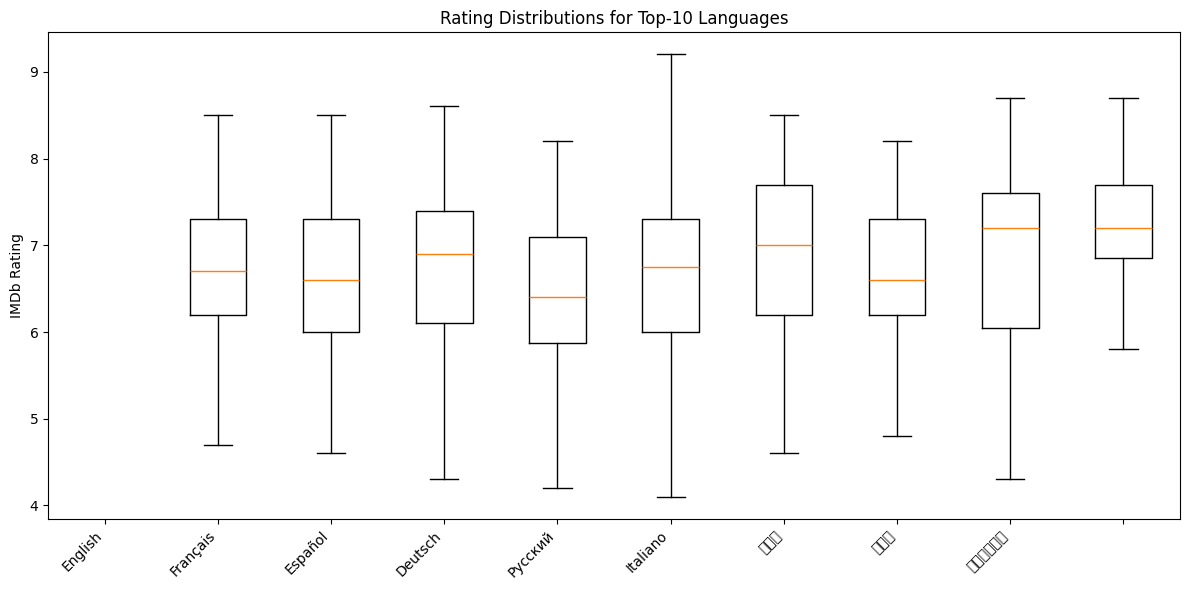

C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\191510944.py:28: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\191510944.py:28: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\191510944.py:28: UserWarning: Glyph 35486 (\N{CJK UNIFIED IDEOGRAPH-8A9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\191510944.py:28: UserWarning: Glyph 26222 (\N{CJK UNIFIED IDEOGRAPH-666E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\191510944.py:28: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\luoya\AppData\Local\Temp\ipykernel_14472\191510944.py:28: UserWarning: Glyph 35805 (\N{CJK 

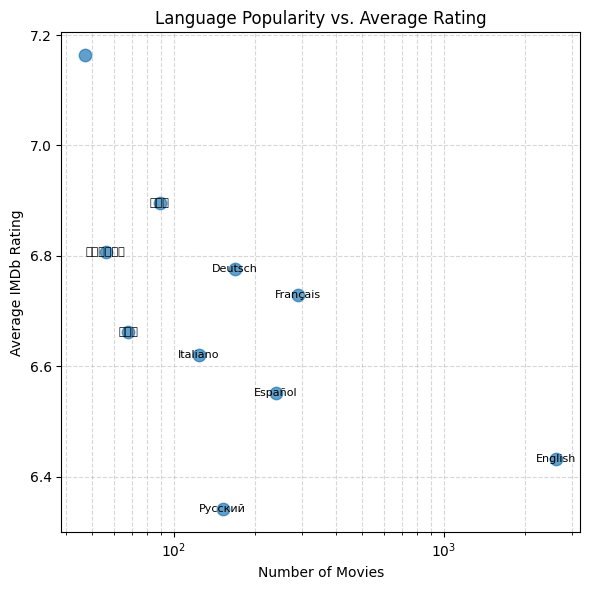

In [35]:
# === Plot A: Rating distributions for Top-10 Languages ===
plt.figure(figsize=(12,6))
box_data_lang = [
    df_lang.loc[df_lang['language'] == lang, 'averageRating']
    for lang in top10
]
plt.boxplot(box_data_lang, tick_labels=top10, showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.ylabel('IMDb Rating')
plt.title('Rating Distributions for Top-10 Languages')
plt.tight_layout()
plt.show()

# === Plot B: Language Popularity vs. Average Rating ===
x_lang = lang_counts.loc[top10]
y_lang = avg_by_lang.loc[top10]   # use avg_by_lang, not avg_rating_by_lang

plt.figure(figsize=(6,6))
plt.scatter(x_lang, y_lang, s=80, alpha=0.7)
for lang in top10:
    plt.text(x_lang[lang], y_lang[lang], lang, fontsize=8, ha='center', va='center')

plt.xscale('log')
plt.xlabel('Number of Movies')
plt.ylabel('Average IMDb Rating')
plt.title('Language Popularity vs. Average Rating')
plt.grid(which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## How Strongly Does Language Influence IMDb Ratings?

### 1. Rating Distributions by Language (Boxplot)

- **Median Differences Are Modest**  
  - The highest‐median language (e.g. “हिन्दी”) is around ~7.7, while the lowest (“Русский”) sits around ~6.3 — a span of **~1.4 points**.  
- **Within‐Language Spread Is Large**  
  - Interquartile ranges for most languages are **1.0–1.5 points**, comparable to the median gaps between languages.  
  - Every language shows films rated from ~4 up to ~9.5, indicating that **individual movie quality** varies widely regardless of language.

### 2. Popularity vs. Average Rating (Scatter)

- **Inverse Trend for Major Languages**  
  - **English** dominates in volume (>2 500 films) but averages **~6.44**, below many smaller‐catalog languages.  
  - Less‐common languages (e.g. Wolof, Somali, Hrvatski) can exhibit **higher average ratings** but are based on very few titles, making them noisy.  
- **Moderate Effect Size**  
  - Languages with mid‐range counts (100–300 titles)—Français, Español, Deutsch—cluster around **6.7**.  
  - Very small datasets (<50 titles) show the highest averages, but these are statistically unreliable “whiskers.”

### 3. Takeaway

- **Language shifts the mean** by **±0.7 points** at most (on a 1–10 scale), a smaller effect than genre’s top spread (~±1.2).  
- **High within‐language variance** means language alone is a **weak predictor** of a single movie’s rating.  
- **Modeling implication:**  
  - **Include** one‐hot language features to capture slight average shifts (e.g. Hindi/Arabic vs. English).  
  - But rely on **richer predictors** (plot keywords, director, cast) to explain the **bulk (>80–90%)** of rating variance.
